<Client: 'tcp://127.0.0.1:61293' processes=4 threads=8, memory=14.90 GiB>
[ColumnTransformer] .......... (1 of 2) Processing nums, total=   2.3s
[ColumnTransformer] ........... (2 of 2) Processing cat, total=   2.0s
Confusion Matrix:
 [[ 519   15]
 [ 152 1383]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.97      0.86       534
           1       0.99      0.90      0.94      1535

    accuracy                           0.92      2069
   macro avg       0.88      0.94      0.90      2069
weighted avg       0.93      0.92      0.92      2069


Train Accuracy: 0.9103
Test Accuracy: 0.9193

ROC AUC Score: 0.9364

Mean Train ROC AUC: 0.9818
Mean Test ROC AUC: 0.9856
Model saved successfully at ../model/Telco_customer_churn.pkl


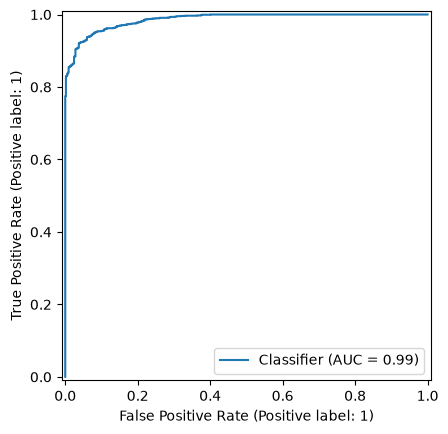

In [ ]:
from load_config import load_config
from dask_ml.wrappers import ParallelPostFit
from sklearn.model_selection import cross_val_score, StratifiedKFold
from dask_ml.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from dask_build_model import build_model
from dask_build_preprocessor import build_preprocessor
from dask_clean_df import clean_df
from dask_cluster import dask_cluster
from dask_create_pkl_file import create_pkl_file
from dask_prepare_feature import prepare_feature
from dask_read_excel import dask_read_excel
import numpy as np
import warnings

warnings.filterwarnings('ignore')


def main():
    config = load_config('config.yaml')
    file_path = config['data']['path']
    random = config['data']['random_state']
    test_size = config['data']['test_size']
    job = config['data']['n_jobs']
    n_splits = config['data']['n_splits']

    client = dask_cluster()

    df = dask_read_excel(file_path)
    df = clean_df(df)

    X, y, df_num, df_cat = prepare_feature(df)

    X = X.persist()
    y = y.persist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random, shuffle=True
    )

    preprocessor = build_preprocessor(
        df, df_num.columns.to_list(), df_cat.columns.to_list()
    )


    model = build_model(preprocessor)
    model.fit(X_train.compute(), y_train.compute())

    clf = ParallelPostFit(model)

    y_pred = clf.predict(X_test.compute())
    y_pred_prob = clf.predict_proba(X_test.compute())[:, 1]

    # Evaluation
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print(f"\nTrain Accuracy: {model.score(X_train.compute(), y_train.compute()):.4f}")
    print(f"Test Accuracy: {model.score(X_test.compute(), y_test.compute()):.4f}")

    print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_pred_prob)

    # Cross-validation
    cv_str = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random)

    score_train = cross_val_score(
        model,
        X=X_train.compute(),
        y=y_train.compute(),
        cv=cv_str,
        n_jobs=job,
        error_score="raise",
        scoring="roc_auc",
    )
    print(f"\nMean Train ROC AUC: {np.mean(score_train):.4f}")

    score_test = cross_val_score(
        model,
        X=X_test.compute(),
        y=y_test.compute(),
        cv=cv_str,
        n_jobs=job,
        error_score="raise",
        scoring="roc_auc",
    )
    print(f"Mean Test ROC AUC: {np.mean(score_test):.4f}")

    create_pkl_file(model)
    client.close()


if __name__ == "__main__":
    main()


NameError: name 'model' is not defined